In [88]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from luwiji.knn import illustration, demo

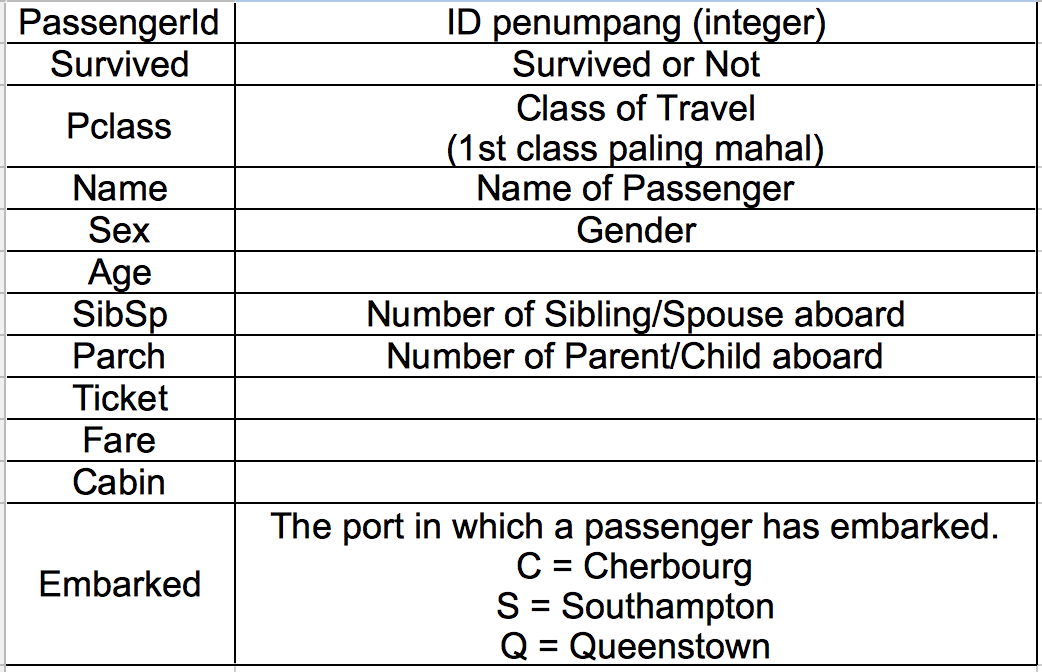

In [89]:
illustration.nomenklatur

In [90]:
df = pd.read_csv("data/titanic.csv", index_col="PassengerId")
df.head()

,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
PassengerId,,,,,,,,,,,
1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S
2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C
3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S
4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S
5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S


In [91]:
df.drop(columns=["Name", "Ticket"], inplace=True)

# Quick Exploratory Data Analysis (Quick EDA)

In [92]:
from jcopml.plot import plot_missing_value

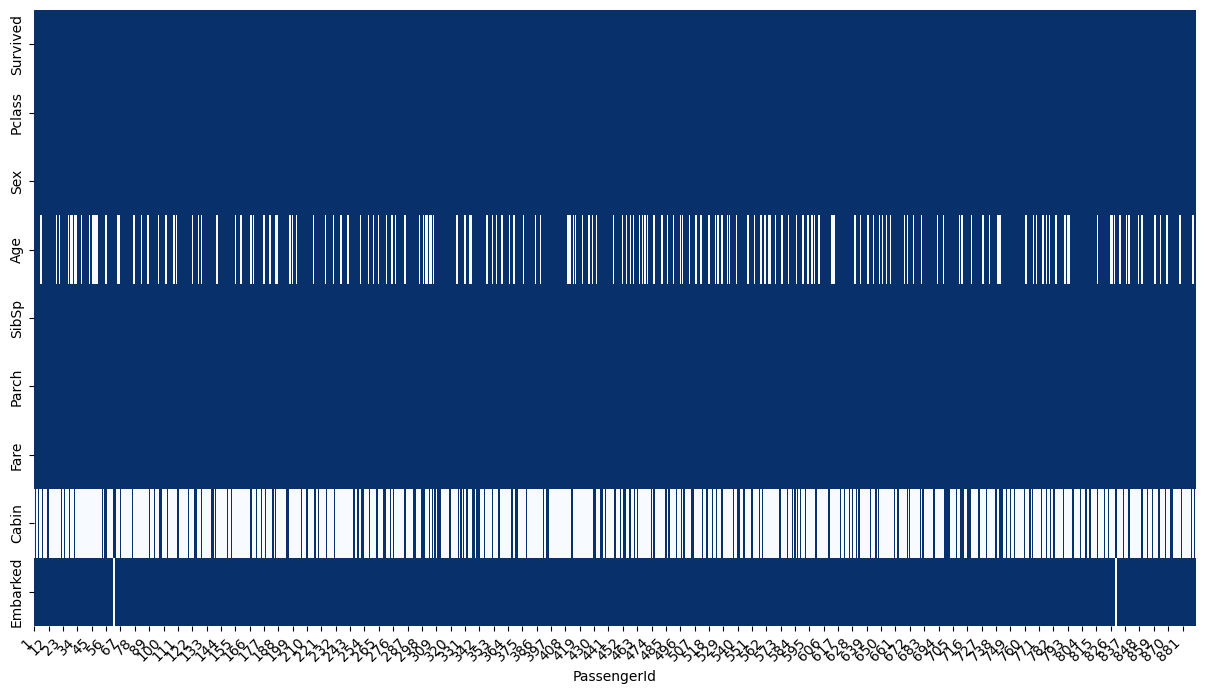

In [93]:
plot_missing_value(df)

In [94]:
df.drop(columns=["Cabin", "Age"], inplace=True)

In [95]:
df["Embarked"].value_counts()

S    644
C    168
Q     77
Name: Embarked, dtype: int64

In [96]:
df.fillna({"Embarked":"S"}, inplace=True)

# Persiapan Data (Data Preprocessing)

In [97]:
X = df.drop(columns=["Survived"])
y = df["Survived"]

X = pd.get_dummies(X, columns=["Pclass", "Sex", "Embarked"])

In [98]:
X

,SibSp,Parch,Fare,Pclass_1,Pclass_2,Pclass_3,Sex_female,Sex_male,Embarked_C,Embarked_Q,Embarked_S
PassengerId,,,,,,,,,,,
1,1,0,7.2500,0,0,1,0,1,0,0,1
2,1,0,71.2833,1,0,0,1,0,1,0,0
3,0,0,7.9250,0,0,1,1,0,0,0,1
4,1,0,53.1000,1,0,0,1,0,0,0,1
5,0,0,8.0500,0,0,1,0,1,0,0,1
...,...,...,...,...,...,...,...,...,...,...,...
887,0,0,13.0000,0,1,0,0,1,0,0,1
888,0,0,30.0000,1,0,0,1,0,0,0,1
889,1,2,23.4500,0,0,1,1,0,0,0,1


In [99]:
y

PassengerId
1      0
2      1
3      1
4      1
5      0
      ..
887    0
888    1
889    0
890    1
891    0
Name: Survived, Length: 891, dtype: int64

# Intro Scikit-learn

In [100]:
from sklearn.neighbors import KNeighborsClassifier

In [101]:
knn = KNeighborsClassifier(n_neighbors=1)
knn.fit(X, y)

KNeighborsClassifier(n_neighbors=1)

In [102]:
knn.score(X, y)

0.8799102132435466

# Concept 1 : Dataset Splitting 

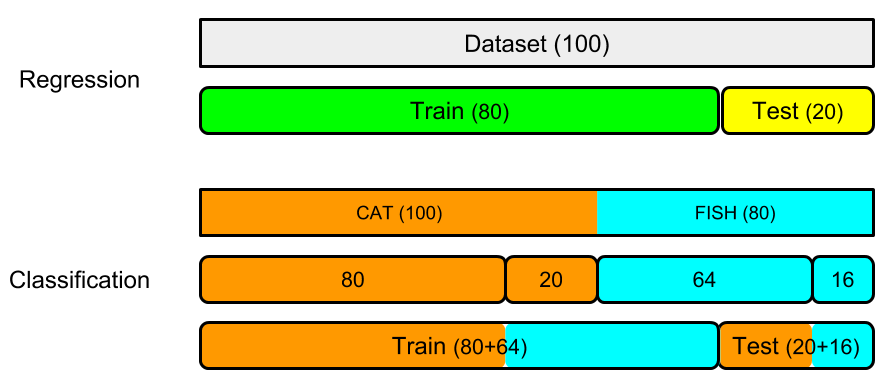

In [103]:
illustration.train_test_split

In [104]:
from sklearn.model_selection import train_test_split

In [105]:
X = df.drop(columns=["Survived"])
y = df["Survived"]

X = pd.get_dummies(X, columns=["Pclass", "Sex", "Embarked"])

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.33, stratify=y, random_state=42)
X_train.shape, X_test.shape, y_train.shape, y_test.shape

((596, 11), (295, 11), (596,), (295,))

In [106]:
knn = KNeighborsClassifier(n_neighbors=1)
knn.fit(X_train, y_train)

KNeighborsClassifier(n_neighbors=1)

In [107]:
knn.score(X_train, y_train),  knn.score(X_test, y_test)

(0.9093959731543624, 0.7593220338983051)

# Concept 2 : K - Fold Cross Validation

In [108]:
from sklearn.model_selection import cross_val_score

In [109]:
knn = KNeighborsClassifier(n_neighbors=1)
cross_val_score(knn, X, y, cv=5)

array([0.61452514, 0.66292135, 0.80898876, 0.70786517, 0.74719101])

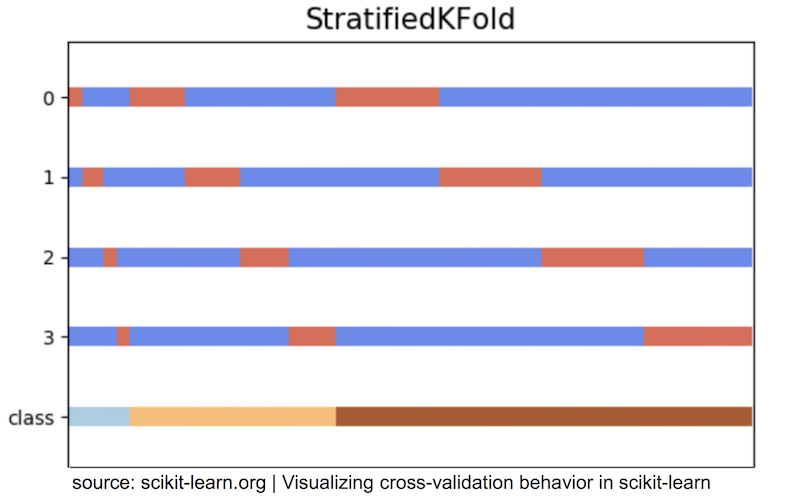

In [110]:
illustration.strat_kfold_cv

# Improve model melalui data : Feature Scalling

In [111]:
demo.knn_scaling()

interactive(children=(IntSlider(value=1, description='N', max=11, min=1, step=2), FloatSlider(value=7000000.0,…

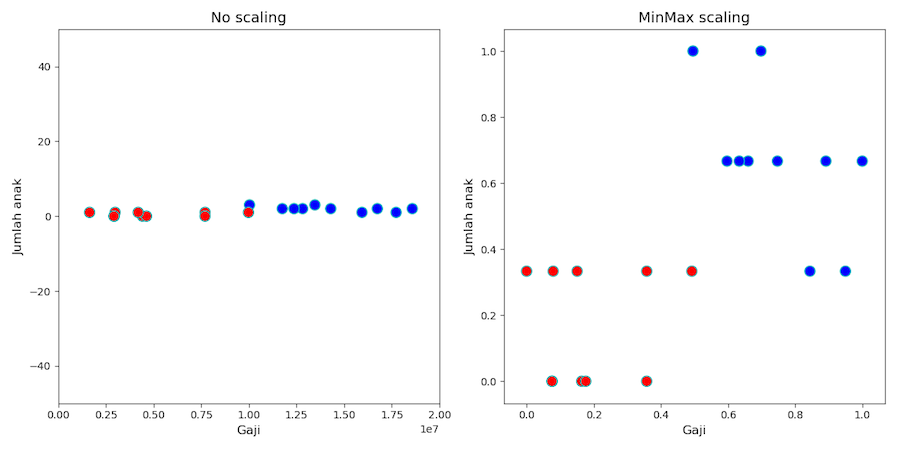

In [112]:
illustration.knn_scaling

In [113]:
from sklearn.preprocessing import MinMaxScaler

In [114]:
scaler = MinMaxScaler()
scaler.fit(X_train)

X_train_scaled = scaler.transform(X_train)
X_test_scaled = scaler.transform(X_test)

In [115]:
knn = KNeighborsClassifier(n_neighbors=1)
knn.fit(X_train_scaled, y_train)

KNeighborsClassifier(n_neighbors=1)

In [116]:
knn.score(X_train_scaled, y_train), knn.score(X_test_scaled, y_test)

(0.9161073825503355, 0.7220338983050848)

# Improvement melalui model : Parameter Tuning

### Tuning n_neighbors tanpa scaling

Max test score = 0.7627118644067796
Max test score = 5


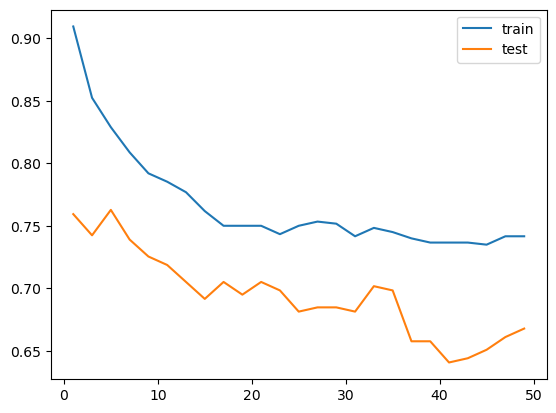

In [124]:
neighbor = range(1, 51, 2)
train_score = []
test_score = []


for k in neighbor:
    knn = KNeighborsClassifier(n_neighbors=k)
    knn.fit(X_train, y_train)

    train_score.append(knn.score(X_train, y_train))
    test_score.append(knn.score(X_test, y_test))

plt.plot(neighbor, train_score, label="train")
plt.plot(neighbor, test_score, label="test")
plt.legend()

print(f"Max test score = {np.max(test_score)}")
print(f"Max test score = {neighbor[np.argmax(test_score)]}")

### Tuning n_nighbors dengan scalingg

Max test score = 0.8169491525423729
Max test score = 27


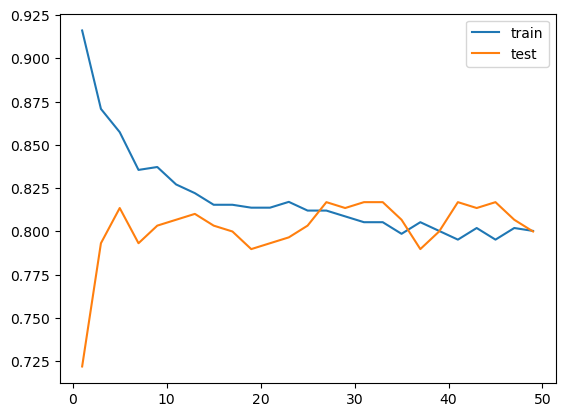

In [126]:
neighbor = range(1, 51, 2)
train_score = []
test_score = []


for k in neighbor:
    knn = KNeighborsClassifier(n_neighbors=k)
    knn.fit(X_train_scaled, y_train)

    train_score.append(knn.score(X_train_scaled, y_train))
    test_score.append(knn.score(X_test_scaled, y_test))

plt.plot(neighbor, train_score, label="train")
plt.plot(neighbor, test_score, label="test")
plt.legend()

print(f"Max test score = {np.max(test_score)}")
print(f"Max test score = {neighbor[np.argmax(test_score)]}")

### Tuning n_neighbor dengan weight by distance

Max test score = 0.8135593220338984
Max test score = 37


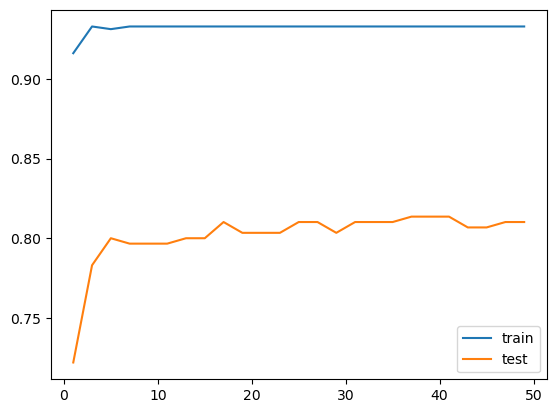

In [127]:
neighbor = range(1, 51, 2)
train_score = []
test_score = []


for k in neighbor:
    knn = KNeighborsClassifier(n_neighbors=k, weights="distance")
    knn.fit(X_train_scaled, y_train)

    train_score.append(knn.score(X_train_scaled, y_train))
    test_score.append(knn.score(X_test_scaled, y_test))

plt.plot(neighbor, train_score, label="train")
plt.plot(neighbor, test_score, label="test")
plt.legend()

print(f"Max test score = {np.max(test_score)}")
print(f"Max test score = {neighbor[np.argmax(test_score)]}")

#### Pakai manhattan distance

Max test score = 0.8135593220338984
Max test score = 41


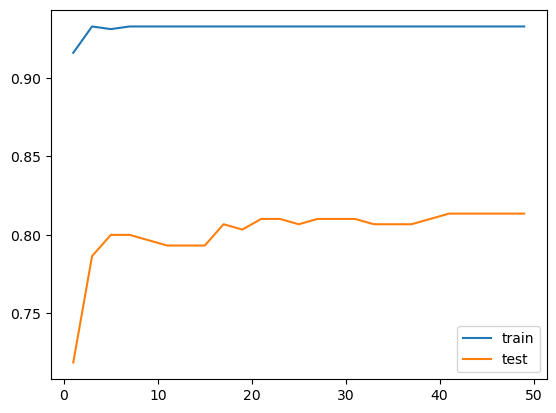

In [128]:
neighbor = range(1, 51, 2)
train_score = []
test_score = []


for k in neighbor:
    knn = KNeighborsClassifier(n_neighbors=k, weights="distance", p=1)
    knn.fit(X_train_scaled, y_train)

    train_score.append(knn.score(X_train_scaled, y_train))
    test_score.append(knn.score(X_test_scaled, y_test))

plt.plot(neighbor, train_score, label="train")
plt.plot(neighbor, test_score, label="test")
plt.legend()

print(f"Max test score = {np.max(test_score)}")
print(f"Max test score = {neighbor[np.argmax(test_score)]}")